In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Generate Synthetic Dataset
np.random.seed(42)
n_samples = 500

data = {
    'CustomerID': [f'CUST-{i:04d}' for i in range(1, n_samples + 1)],
    'Age': np.random.randint(18, 70, size=n_samples),
    'Tenure_Months': np.random.randint(1, 60, size=n_samples),
    'Monthly_Charges': np.round(np.random.uniform(20.0, 120.0, size=n_samples), 2),
    'Contract_Type': np.random.choice(['Month-to-Month', 'One-Year', 'Two-Year'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'Tech_Support': np.random.choice(['Yes', 'No'], size=n_samples, p=[0.4, 0.6]),
    'Churn': np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
}

df = pd.DataFrame(data)
print("Dataset created successfully!\n")

# 2. Preview Data
print("First 5 rows:")
print(df.head())

# 3. Data Preprocessing
le = LabelEncoder()
df['Contract_Type'] = le.fit_transform(df['Contract_Type'])
df['Tech_Support'] = le.fit_transform(df['Tech_Support'])

X = df[['Age', 'Tenure_Months', 'Monthly_Charges', 'Contract_Type', 'Tech_Support']]
y = df['Churn']

# FIXED LINE: test_size=0.2 instead of test_score=0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Model Evaluation
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Dataset created successfully!

First 5 rows:
  CustomerID  Age  Tenure_Months  Monthly_Charges   Contract_Type  \
0  CUST-0001   56             16            86.76  Month-to-Month   
1  CUST-0002   69             39            37.23  Month-to-Month   
2  CUST-0003   46              5            39.23        One-Year   
3  CUST-0004   32             22            24.09  Month-to-Month   
4  CUST-0005   60             29            36.89  Month-to-Month   

  Tech_Support  Churn  
0          Yes      0  
1          Yes      0  
2          Yes      1  
3           No      0  
4          Yes      1  

Model Accuracy: 59.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.86      0.74        66
           1       0.18      0.06      0.09        34

    accuracy                           0.59       100
   macro avg       0.41      0.46      0.41       100
weighted avg       0.48      0.59      0.52       100



In [3]:
# Create requirements.txt
requirements_content = """pandas>=1.3.0
numpy>=1.21.0
scikit-learn>=1.0.0
matplotlib>=3.4.0
seaborn>=0.11.0
"""
with open("requirements.txt", "w") as f:
    f.write(requirements_content)

# Create README.md
readme_content = """# Customer Churn Analytics and AI Prediction

## Overview
An end-to-end Data Analytics and AI Machine Learning solution to predict customer churn risk using customer interaction features.

## Project Deliverables
- `SyedaSaniyaKouser_CustomerChurn.ipynb`: Primary Python source code with EDA and ML model training.
- `requirements.txt`: Environment configuration and dependencies.
- `SyedaSaniyaKouser_ProjectReport.docx`: Detailed project technical documentation.

## How to Run
1. Install dependencies: `pip install -r requirements.txt`
2. Run `SyedaSaniyaKouser_CustomerChurn.ipynb` in Google Colab or VS Code.
"""
with open("README.md", "w") as f:
    f.write(readme_content)

print("requirements.txt and README.md created successfully!")

requirements.txt and README.md created successfully!


/tmp/ipykernel_1323/1792146303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


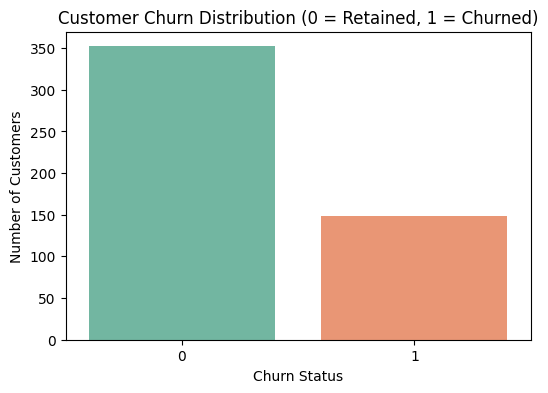

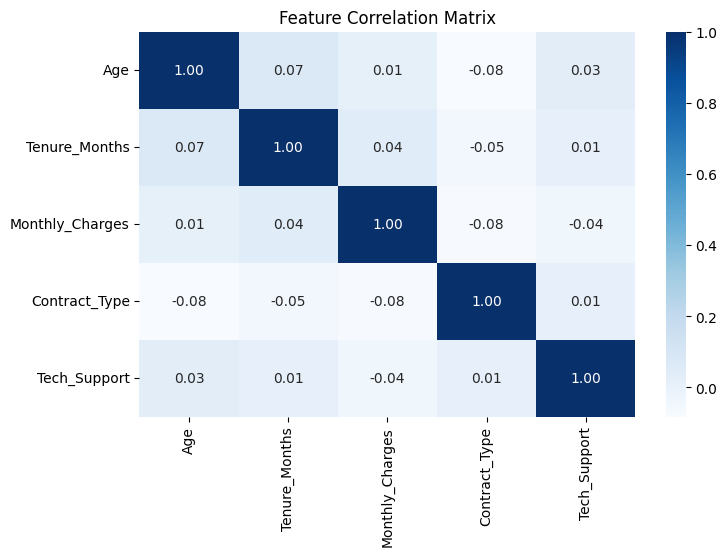

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot Churn Count
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution (0 = Retained, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

# 2. Plot Feature Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(X.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()